# Multilayer Perceptron (MLP) - PyTorch

In [2]:
import os
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 1. REPRODUCIBILITY SETUP
# ---------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------
# 2. DATA PREPARATION & OPTIMIZATION
# ---------------------------------------------------------
iris = load_iris()
X = StandardScaler().fit_transform(iris.data).astype("float32")
y = iris.target.astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

# PyTorch Optimization: Move the entire dataset to the device ONCE.
# For small datasets like Iris, this avoids the overhead of CPU-to-GPU
# transfers for every single batch in the training loop.
X_train_t = torch.tensor(X_train, device=device)
y_train_t = torch.tensor(y_train, device=device)
test_x = torch.tensor(X_test, device=device)
test_y = torch.tensor(y_test, device=device)

# Increased batch_size to 32 for smoother gradients
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32,
    shuffle=True,
)

# ---------------------------------------------------------
# 3. MODEL ARCHITECTURE
# ---------------------------------------------------------
class MLPClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_classes: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3), # Increased dropout
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2), # Added second dropout

            # No Softmax needed: nn.CrossEntropyLoss applies Softmax internally
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

model = MLPClassifier(input_dim=4, hidden_dim=32, num_classes=3).to(device)

# Lowered learning rate for stability
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# ---------------------------------------------------------
# 4. TRAINING LOOP
# ---------------------------------------------------------
# Tracking history to match Keras functionality
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
epochs = 100

print("\nStarting Training...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for features, labels in train_loader:
        # Note: No need to use .to(device) here; data is already on the GPU/CPU

        # PyTorch Optimization: set_to_none=True slightly improves memory performance
        optimizer.zero_grad(set_to_none=True)

        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Track training metrics
        epoch_loss += loss.item() * features.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_loss = epoch_loss / total
    train_acc = correct / total

    # PyTorch Optimization: inference_mode is faster than no_grad
    model.eval()
    with torch.inference_mode():
        val_outputs = model(test_x)
        val_loss = criterion(val_outputs, test_y).item()
        val_acc = (val_outputs.argmax(dim=1) == test_y).float().mean().item()

    # Save to history dictionary
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:03d}/{epochs}] | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}")

print(f"\nFinal validation accuracy: {history['val_accuracy'][-1]:.4f}")

Using device: cpu

Starting Training...
Epoch [020/100] | Val Loss: 0.8762 | Val Accuracy: 0.7895
Epoch [040/100] | Val Loss: 0.5364 | Val Accuracy: 0.7632
Epoch [060/100] | Val Loss: 0.3863 | Val Accuracy: 0.8421
Epoch [080/100] | Val Loss: 0.3174 | Val Accuracy: 0.8421
Epoch [100/100] | Val Loss: 0.2622 | Val Accuracy: 0.8684

Final validation accuracy: 0.8684


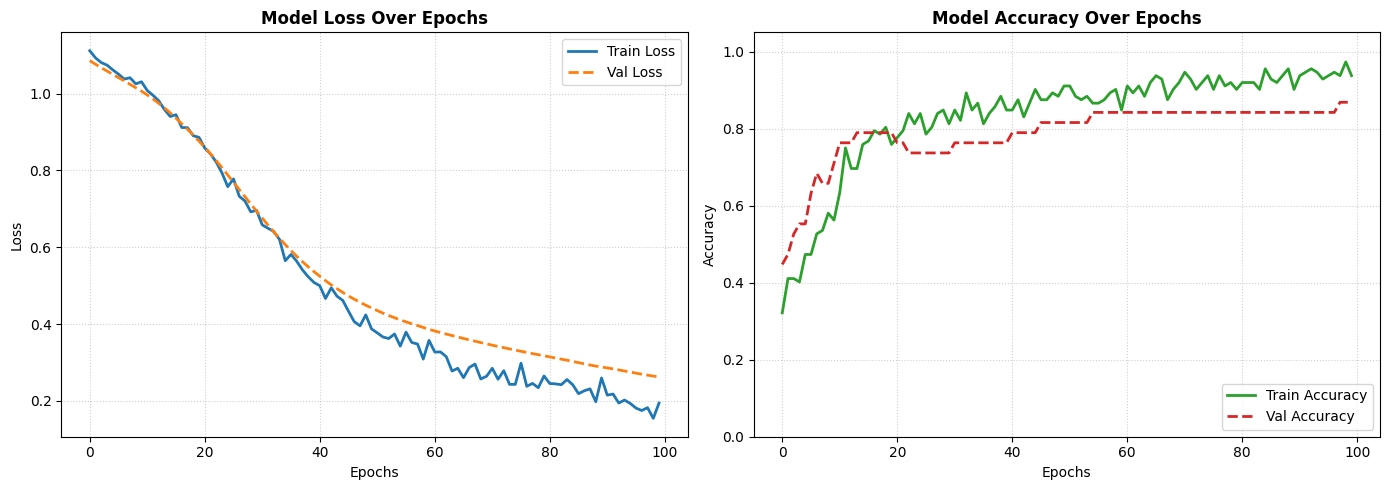

In [3]:
import matplotlib.pyplot as plt

# Create a side-by-side subplot figure for Loss and Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── PLOT 1: CROSS-ENTROPY LOSS ───────────────────────────────────────────────
ax1.plot(history['loss'], label='Train Loss', color='#1f77b4', lw=2)
ax1.plot(history['val_loss'], label='Val Loss', color='#ff7f0e', lw=2, linestyle='--')
ax1.set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend(frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# ── PLOT 2: ACCURACY ──────────────────────────────────────────────────────────
ax2.plot(history['accuracy'], label='Train Accuracy', color='#2ca02c', lw=2)
ax2.plot(history['val_accuracy'], label='Val Accuracy', color='#d62728', lw=2, linestyle='--')
ax2.set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.0, 1.05)  # Constrain accuracy between 0 and 100%
ax2.legend(frameon=True, loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()